# **기본 설정 및 라이브러리 로드**

In [16]:
!pip3 install torch
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# **드라이브마운트**

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Now using {device}.")
from google.colab import drive
drive.mount('/content/drive')


Now using cuda.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **데이터 증강 및 전처리 설정**

In [18]:
transform = transforms.Compose([
    transforms.RandomRotation(10),  # 이미지를 -10도에서 +10도 사이로 랜덤 회전
    transforms.RandomAffine(0, translate=(0.1, 0.1)),  # 이미지의 10% 내외에서 랜덤 이동
    transforms.ToTensor(),  # 이미지를 PyTorch 텐서 형태로 변환
    transforms.Normalize((0.5,), (0.5,))  # 평균과 표준편차를 사용하여 이미지 정규화
])

Transforms.Compose로 데이터 증강 기법을 설정하고 회전과 이동을 추가하여 모델의 일반화 성능을 높이고, 정규화를 통해 모델이 데이터의 범위에 독립적으로 학습할 수 있도록 합니다.

# **데이터셋 로드 및 DataLoader 설정**

In [19]:

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)  # 학습용
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transforms.Compose([
    transforms.ToTensor(),  # 이미지 텐서 변환
    transforms.Normalize((0.5,), (0.5,))  # 정규화
]))

# 데이터 로더를 정의하여 배치 크기 64로 설정
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)  # 학습 데이터 로더
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)  # 테스트 데이터 로더

학습과 테스트용 데이터셋을 불러와 학습에 필요한 전처리 과정을 적용하고 Dataloder는 batchSizer를 설정하여 데이터를 배치 단위로 묶어주고 shuffle=TRUE로 학습데이터는 순서를 무작위로 썩어 모델의 일반화 성능을 높히도록합니다

# **데이터 시각화**

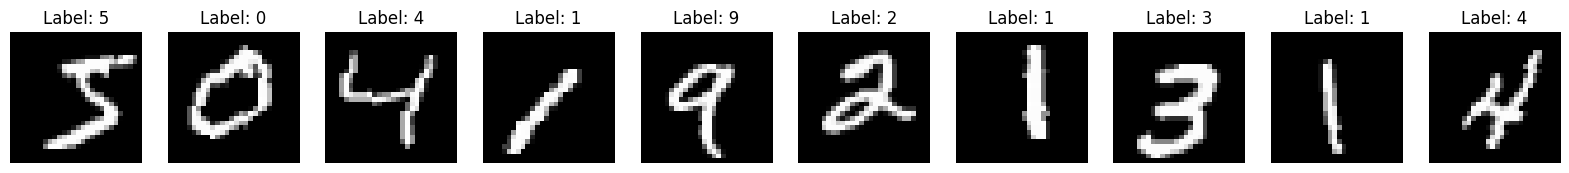

In [20]:
# 데이터셋 이미지와 라벨을 시각화하는 함수 정의
def show_images_with_labels(dataset, num_images=10):
    fig, axes = plt.subplots(1, num_images, figsize=(20, 20))  # 이미지 출력 창 설정
    for i in range(num_images):
        image, label = dataset[i]  # 이미지와 라벨 추출
        axes[i].imshow(image.squeeze(), cmap='gray')  # 이미지 출력
        axes[i].set_title(f'Label: {label}')  # 이미지 제목에 라벨 설정
        axes[i].axis('off')  # 축 없애기
    plt.show()

    # 학습 데이터셋에서 이미지 10개를 출력하여 시각화
show_images_with_labels(train_dataset, num_images=10)

데이터셋에서 num_images만큼의 이미지를 가져와 시각화하는데 squeez로 이미지 텐서를 2D배열로 변환하고, imshow와 set_title을 통해 이미지와 라벨을 시각화합니다

# **모델 정의**

In [21]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5, stride=1, padding=2)  # 첫 번째 합성곱 레이어
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=2)  # 두 번째 합성곱 레이어
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)  # 맥스 풀링 레이어
        self.fc1 = nn.Linear(32 * 7 * 7, 128)  # 첫 번째 완전 연결 레이어
        self.fc2 = nn.Linear(128, 10)  # 두 번째 완전 연결 레이어
        self.relu = nn.ReLU()  # 활성화 함수로 ReLU 사용

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # 첫 번째 합성곱과 ReLU, 풀링
        x = self.pool(self.relu(self.conv2(x)))  # 두 번째 합성곱과 ReLU, 풀링
        x = x.view(-1, 32 * 7 * 7)  # 특징 맵을 일렬로 펼침
        x = self.relu(self.fc1(x))  # 첫 번째 완전 연결 레이어와 ReLU
        x = self.fc2(x)  # 두 번째 완전 연결 레이어
        return x

클래스로 CNN모델을 정의하며, forward()메서드에서 입력텐서가 각 레이어를 통과하는 방식을 설정하고 con2d레이어는 필터를 사용해 특징을 추출하며, MaxPoll2d는 다운샘플링을 통해특징을 압축합니다 마지막으로 리니어 레이어로 분류를 수행하며, ReLU활성함수를 통해 비선형성을 부여합니다.

In [22]:
# 모델 디렉토리 생성 및 모델 초기화
model_dir = './model'
os.makedirs(model_dir, exist_ok=True)
model = CNN().to(device)  # 모델을 지정한 장치에 할당

# 손실 함수 및 옵티마이저 정의
criterion = nn.CrossEntropyLoss()  # 다중 클래스 분류에 적합한 손실 함수
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam 최적화 알고리즘 사용

# **FGSM 함수 정의**

In [23]:

def fgsm_attack(image, epsilon, data_grad):
    sign_data_grad = data_grad.sign()  # 기울기의 부호를 구함
    perturbed_image = image + epsilon * sign_data_grad  # 기울기 방향으로 perturbation 추가
    return torch.clamp(perturbed_image, 0, 1)  # 픽셀 값을 0과 1 사이로 제한

fgsm_attack함수를 통해 FGSM공격을 수행하며 각 픽셀을 데이터 기울기의 부호화 epsilon의 값에 따라 왜곡시켜 적대적이미지를 생성합니다.

# **모델 학습 및 점진적 적대적 학습 추가**

In [24]:
# 학습 및 점진적 적대적 학습 설정
num_epochs = 5  # 총 학습 에포크 수
initial_epsilon = 0.1  # 초기 perturbation 크기
final_epsilon = 0.7  # 최종 perturbation 크기

for epoch in range(num_epochs):
    # 에포크마다 epsilon 증가
    epsilon = initial_epsilon + (final_epsilon - initial_epsilon) * (epoch / (num_epochs - 1))
    model.train()  # 모델을 학습 모드로 전환
    running_loss = 0.0  # 손실 초기화

    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)  # 이미지와 라벨을 장치에 할당
        images.requires_grad = True  # 이미지에 대한 기울기 계산 활성화
        outputs = model(images)  # 모델 예측
        loss = criterion(outputs, labels)  # 손실 계산
        model.zero_grad()  # 기존 기울기 초기화
        loss.backward()  # 역전파 수행

        data_grad = images.grad.data  # 기울기 저장
        perturbed_images = fgsm_attack(images, epsilon, data_grad)  # FGSM 공격 수행하여 적대적 예제 생성

        optimizer.zero_grad()  # 옵티마이저 기울기 초기화

        outputs_original = model(images)  # 원본 이미지 예측
        loss_original = criterion(outputs_original, labels)  # 원본 이미지 손실 계산

        outputs_perturbed = model(perturbed_images)  # 적대적 이미지 예측
        loss_perturbed = criterion(outputs_perturbed, labels)  # 적대적 이미지 손실 계산

        loss = (loss_original + loss_perturbed) / 2  # 평균 손실 계산
        loss.backward()  # 역전파
        optimizer.step()  # 파라미터 업데이트

        running_loss += loss.item()  # 손실 값 누적

        # 100번째 배치마다 학습 상태 출력
        if (i+1) % 100 == 0:
            current_lr = optimizer.param_groups[0]['lr']  # 학습률
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], '
                  f'Loss: {running_loss/100:.4f}, Epsilon: {epsilon:.3f}, Learning Rate: {current_lr}')
            running_loss = 0.0


Epoch [1/5], Step [100/938], Loss: 1.2083, Epsilon: 0.100, Learning Rate: 0.001
Epoch [1/5], Step [200/938], Loss: 0.5111, Epsilon: 0.100, Learning Rate: 0.001
Epoch [1/5], Step [300/938], Loss: 0.3661, Epsilon: 0.100, Learning Rate: 0.001
Epoch [1/5], Step [400/938], Loss: 0.3193, Epsilon: 0.100, Learning Rate: 0.001
Epoch [1/5], Step [500/938], Loss: 0.2721, Epsilon: 0.100, Learning Rate: 0.001
Epoch [1/5], Step [600/938], Loss: 0.2468, Epsilon: 0.100, Learning Rate: 0.001
Epoch [1/5], Step [700/938], Loss: 0.2314, Epsilon: 0.100, Learning Rate: 0.001
Epoch [1/5], Step [800/938], Loss: 0.1913, Epsilon: 0.100, Learning Rate: 0.001
Epoch [1/5], Step [900/938], Loss: 0.1907, Epsilon: 0.100, Learning Rate: 0.001
Epoch [2/5], Step [100/938], Loss: 0.3130, Epsilon: 0.250, Learning Rate: 0.001
Epoch [2/5], Step [200/938], Loss: 0.2988, Epsilon: 0.250, Learning Rate: 0.001
Epoch [2/5], Step [300/938], Loss: 0.2479, Epsilon: 0.250, Learning Rate: 0.001
Epoch [2/5], Step [400/938], Loss: 0.244

num_epochs동안 모델을 학습하면서 epsilon을 점진적으로 증가시킵니다. 원본 이미지와 FGSM공격으로 생성된 적대적 이미지를 모두 사용하여 학습해 모델의 적대적 공격에 대한 견고성을 높입니다.

In [25]:
# 학습된 모델 가중치 저장
model_path = os.path.join(model_dir, 'CNN_mnist.pth')
torch.save(model.state_dict(), model_path)

# **모델 평가 및 예측 시각화**

Accuracy of the model on the 10000 test images: 98.97%
Image 1:
Label: 7
Prediction: 7


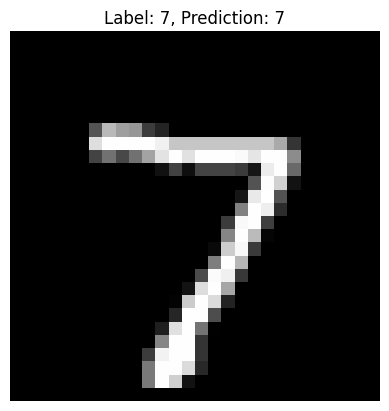

Image 2:
Label: 2
Prediction: 2


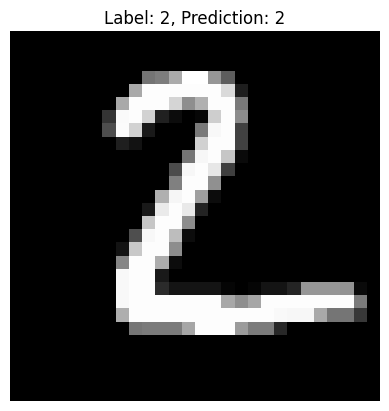

Image 3:
Label: 1
Prediction: 1


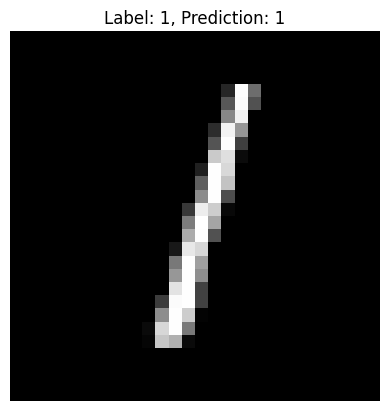

Image 4:
Label: 0
Prediction: 0


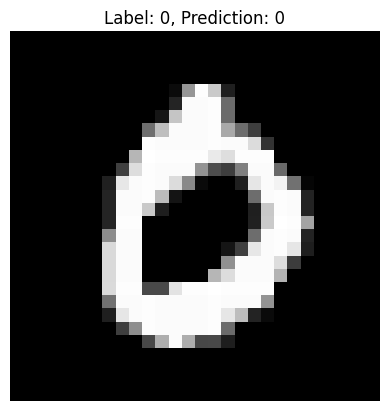

Image 5:
Label: 4
Prediction: 4


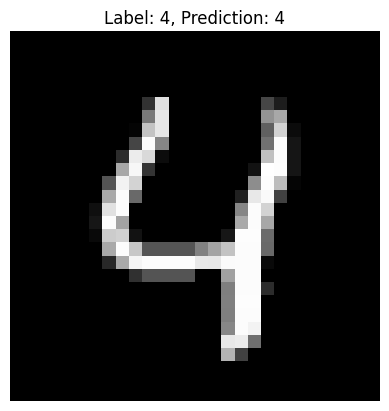

Image 6:
Label: 1
Prediction: 1


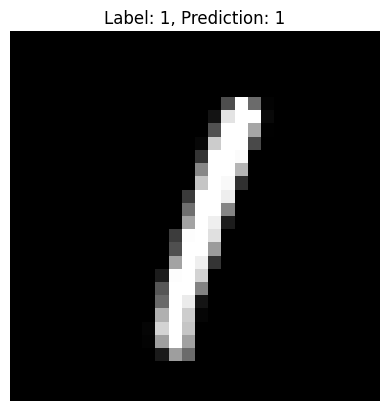

Image 7:
Label: 4
Prediction: 4


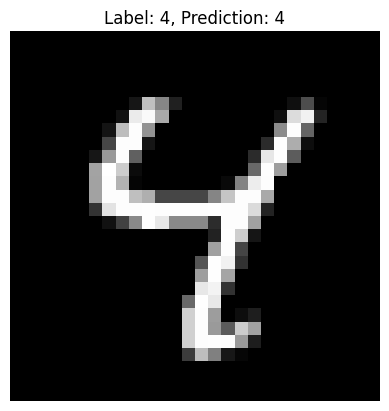

Image 8:
Label: 9
Prediction: 9


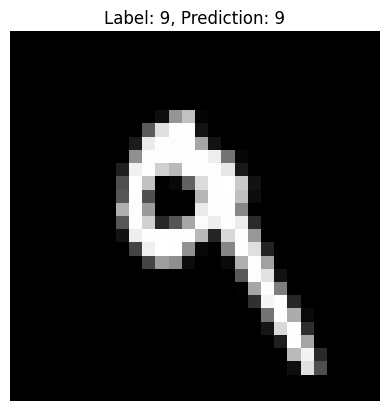

Image 9:
Label: 5
Prediction: 5


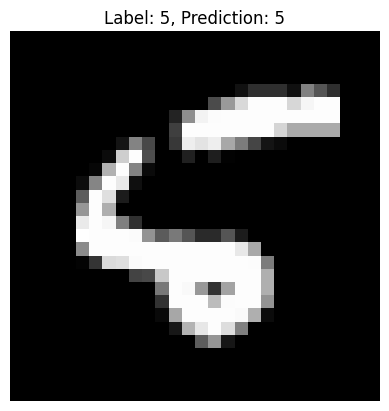

Image 10:
Label: 9
Prediction: 9


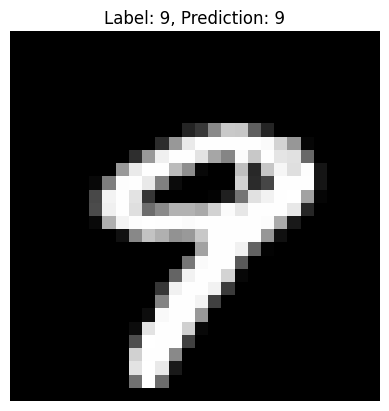

In [26]:
model.eval()  # 모델을 평가 모드로 설정하여 드롭아웃 및 배치 정규화 레이어가 고정된 동작을 수행하도록 함
correct = 0   # 맞게 예측한 개수를 저장할 변수 초기화
total = 0     # 전체 이미지 개수를 저장할 변수 초기화

# 평가를 위한 그라디언트 비활성화
with torch.no_grad():
    # 테스트 데이터셋을 반복하여 로드
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)  # 이미지를 GPU로 이동
        outputs = model(images)  # 모델을 통해 이미지를 예측
        _, predicted = torch.max(outputs.data, 1)  # 예측된 라벨 중 확률이 가장 높은 값을 선택
        total += labels.size(0)  # 전체 이미지 개수에 현재 배치 이미지 개수를 더함
        correct += (predicted == labels).sum().item()  # 예측이 맞은 이미지 개수를 더함

print(f'Accuracy of the model on the 10000 test images: {100 * correct / total:.2f}%')  # 전체 정확도 출력

# 예측 시각화 함수 정의
def imshow(img, title):
    img = img.detach().cpu().numpy().squeeze()  # GPU 텐서를 CPU로 이동 및 Numpy 배열로 변환
    plt.imshow(img, cmap='gray')  # 이미지 시각화
    plt.title(title)  # 제목 설정
    plt.axis('off')  # 축 숨김
    plt.show()

test_images = []       # 시각화용 테스트 이미지 리스트
test_labels = []       # 시각화용 실제 라벨 리스트
test_predictions = []  # 시각화용 예측 라벨 리스트

# 시각화용 테스트 데이터 저장
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)  # 데이터를 GPU로 이동
        outputs = model(images)  # 모델을 통해 예측 수행
        _, predicted = torch.max(outputs.data, 1)  # 예측된 라벨 중 가장 확률 높은 값 선택

        # 10개의 이미지를 저장할 때까지 반복
        if len(test_images) < 10:
            test_images.append(images.cpu())  # GPU 텐서를 CPU로 이동 후 리스트에 추가
            test_labels.append(labels.cpu())  # 실제 라벨을 리스트에 추가
            test_predictions.append(predicted.cpu())  # 예측 라벨을 리스트에 추가

        if len(test_images) >= 10:  # 10개의 이미지를 저장한 후 루프 탈출
            break

# 리스트에 저장된 이미지를 텐서로 결합하여 첫 10개의 이미지만 선택
test_images = torch.cat(test_images)[:10]
test_labels = torch.cat(test_labels)[:10]
test_predictions = torch.cat(test_predictions)[:10]

# 10개의 이미지와 예측 결과 출력 및 시각화
for i in range(10):
    print(f"Image {i+1}:")  # 이미지 번호 출력
    print(f"Label: {test_labels[i].item()}")  # 실제 라벨 출력
    print(f"Prediction: {test_predictions[i].item()}")  # 예측 라벨 출력
    imshow(test_images[i], title=f"Label: {test_labels[i].item()}, Prediction: {test_predictions[i].item()}")  # 이미지 시각화

model.eval을 통해 모델을 평가모드로 설정하고 그래디언트 계산을 비활성화하여 효율적으로 동작하도록합니다 테스트 로더로 전체 테스트 데이터셋을 배치 단위로 반복하고 각 이미지의 옟그 결과를 비교하여 맞은 예측개수를 누적합니다. 이 후 예측결과를 시각화하고 반복하여 10개의 이미지를 저장하고 그에 대한 예측과 실제 라벨을 리스트에 저장합니다 마지막으로 각 이미지에 대해 실제 라벨과 예측 라벨을 표시하여 시각화합니다

# **FGSM공격 실행 및 이미지 생성과 예측**

Image 1:
Original Label: 7
Initial Prediction: 7
Final Prediction: 7 (Attack failed)


<ipython-input-27-be3b6cfa158b>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))  # 저장된 모델 가중치를 불러와서 모델에 로드


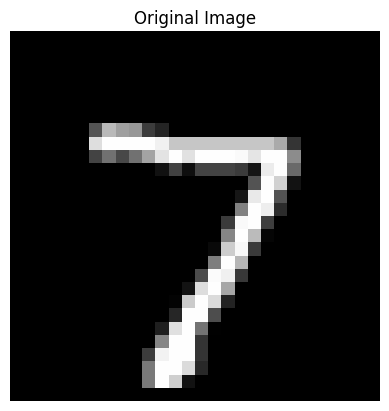

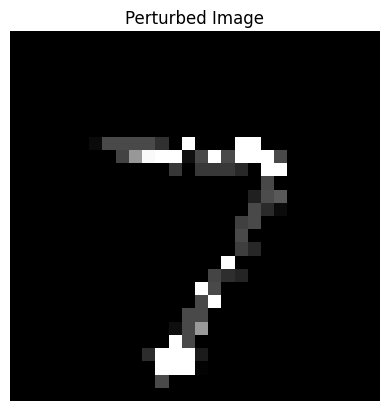

Image 2:
Original Label: 2
Initial Prediction: 2
Final Prediction: 2 (Attack failed)


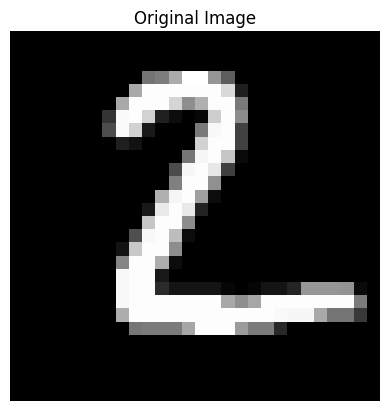

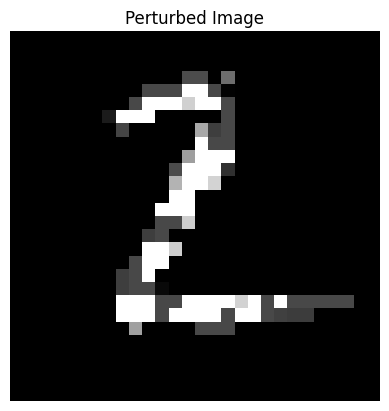

Image 3:
Original Label: 1
Initial Prediction: 1
Final Prediction: 1 (Attack failed)


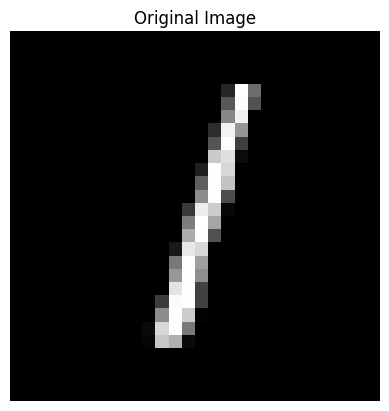

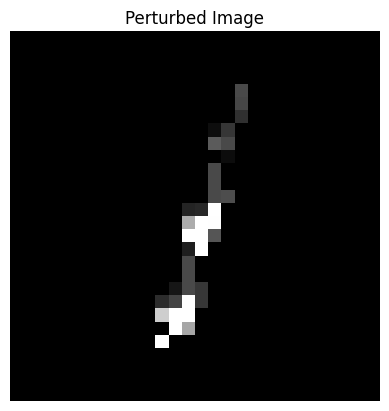

Image 4:
Original Label: 0
Initial Prediction: 0
Final Prediction: 0 (Attack failed)


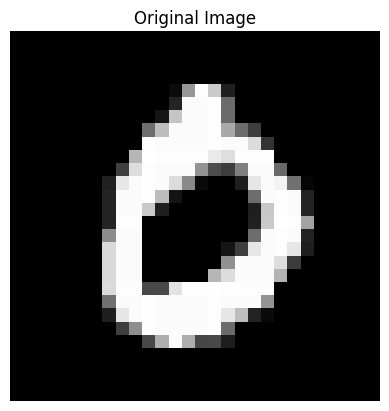

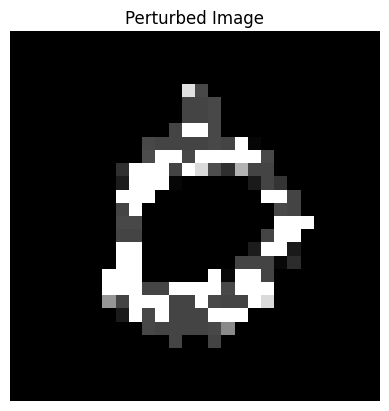

Image 5:
Original Label: 4
Initial Prediction: 4
Final Prediction: 4 (Attack failed)


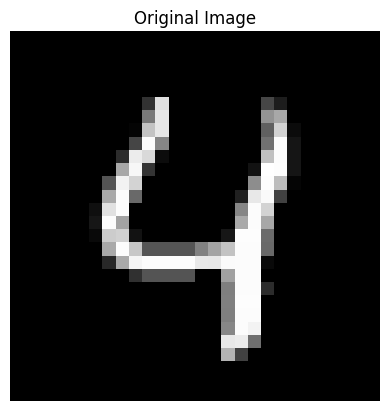

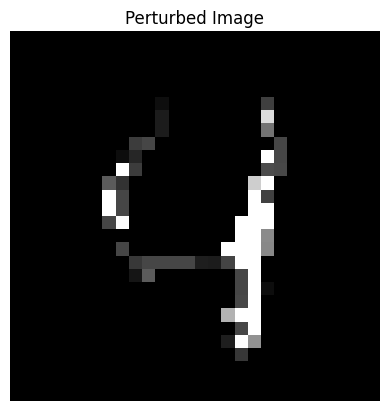

Image 6:
Original Label: 1
Initial Prediction: 1
Final Prediction: 1 (Attack failed)


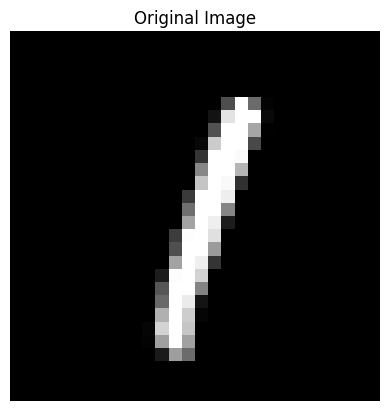

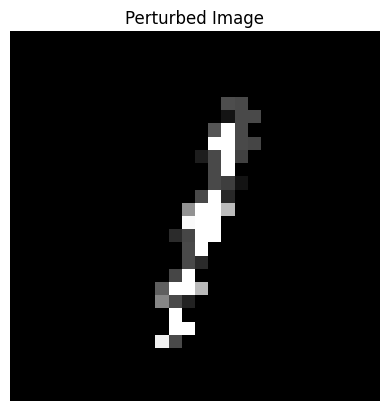

Image 7:
Original Label: 4
Initial Prediction: 4
Final Prediction: 4 (Attack failed)


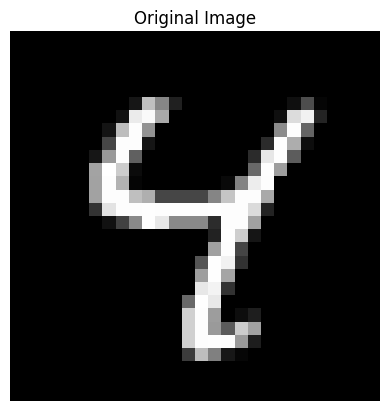

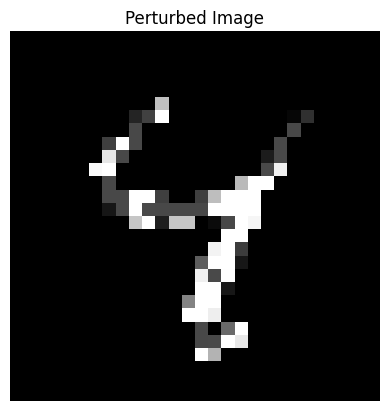

Image 8:
Original Label: 9
Initial Prediction: 9
Final Prediction: 9 (Attack failed)


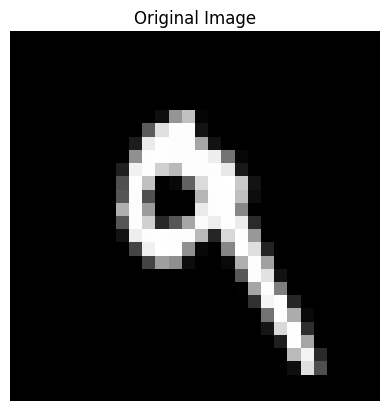

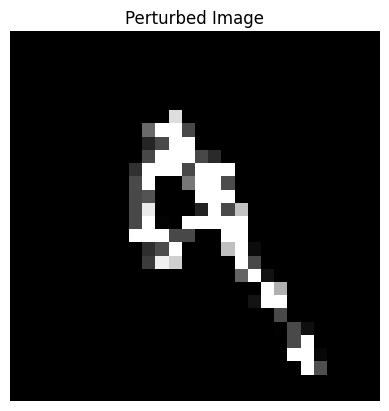

Image 9:
Original Label: 5
Initial Prediction: 5
Final Prediction: 5 (Attack failed)


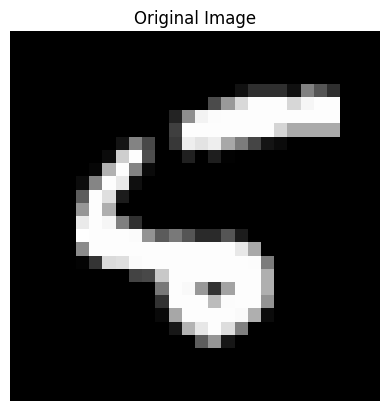

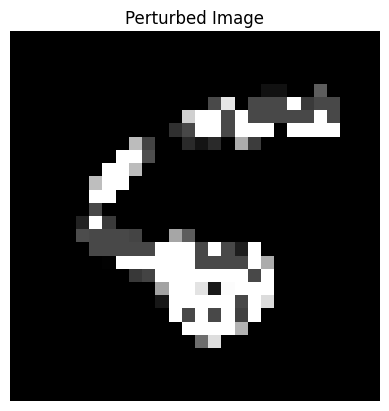

Image 10:
Original Label: 9
Initial Prediction: 9
Final Prediction: 9 (Attack failed)


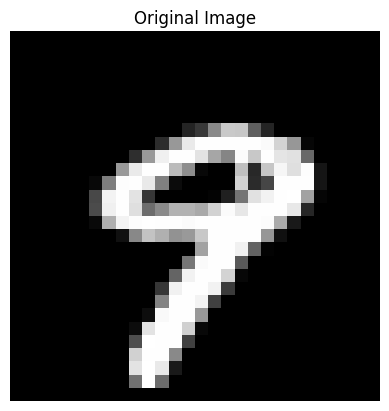

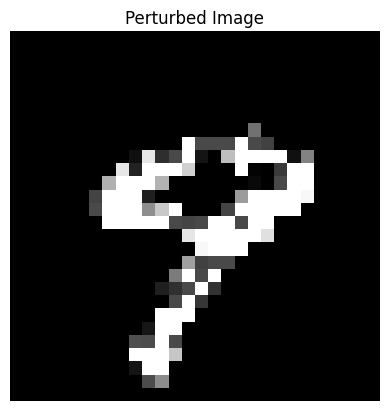

Accuracy after FGSM attack: 100.00%


In [27]:
# FGSM 공격을 사용한 적대적 이미지 생성 및 예측

model.load_state_dict(torch.load(model_path))  # 저장된 모델 가중치를 불러와서 모델에 로드
data_iter = iter(test_loader)  # 테스트 데이터 로더를 반복 가능한 객체로 변환
images, labels = next(data_iter)  # 테스트 데이터셋에서 첫 번째 배치 (이미지와 라벨)를 가져옴
images, labels = images[:10].to(device), labels[:10].to(device)  # 배치에서 처음 10개의 이미지를 선택하고 GPU로 이동
images.requires_grad = True  # 이미지 텐서의 그라디언트를 활성화하여 FGSM 공격에 필요한 그라디언트를 계산할 수 있게 함

outputs = model(images)  # 모델을 통해 원본 이미지의 예측값을 얻음
init_preds = outputs.max(1, keepdim=True)[1]  # 예측된 클래스 중 가장 확률이 높은 값을 선택하여 초기 예측을 저장
loss = nn.CrossEntropyLoss()(outputs, labels)  # 예측값과 실제 라벨 간의 손실 계산 (CrossEntropy 사용)
model.zero_grad()  # 이전에 계산된 그라디언트를 모두 초기화
loss.backward()  # 역전파하여 이미지에 대한 그라디언트 계산

data_grads = images.grad.data  # 계산된 그라디언트를 저장
epsilon = 0.7  # FGSM 공격 강도를 설정
perturbed_images = fgsm_attack(images, epsilon, data_grads)  # FGSM 공격 함수 사용하여 적대적 예제를 생성

outputs = model(perturbed_images)  # 적대적 예제를 통해 예측값을 다시 계산
final_preds = outputs.max(1, keepdim=True)[1]  # 적대적 예제에서의 최종 예측 클래스 선택

# 결과 시각화 및 예측 정확도 계산
correct = 0  # 공격 성공률을 계산하기 위해 올바른 예측 수를 저장
total = len(labels)  # 전체 라벨의 수 (여기서는 10)

# 각 적대적 예제에 대해 예측 결과를 출력하고 정확도를 계산
for i in range(total):
    print(f"Image {i+1}:")
    print(f"Original Label: {labels[i].item()}")  # 원본 라벨 출력
    print(f"Initial Prediction: {init_preds[i].item()}")  # 원본 이미지에 대한 초기 예측 출력
    print(f"Final Prediction: {final_preds[i].item()} {'(Attack failed)' if final_preds[i].item() == labels[i].item() else ''}")
    # 적대적 예제에서의 최종 예측과 원본 라벨이 동일한 경우 공격이 실패한 것으로 간주

    # 정확도 계산을 위해 공격이 실패한 (최종 예측이 원본 라벨과 같은) 경우에 correct를 증가
    if final_preds[i].item() == labels[i].item():
        correct += 1

    imshow(images[i], title="Original Image")  # 원본 이미지를 시각화
    imshow(perturbed_images[i], title="Perturbed Image")  # 적대적 예제를 시각화

# 적대적 이미지에 대한 예측 정확도 출력
accuracy = 100 * correct / total  # 전체 이미지 중 공격이 실패한 비율을 계산하여 정확도로 출력
print(f"Accuracy after FGSM attack: {accuracy:.2f}%")  # 최종 공격 후 모델의 정확도 출력


F사전에 학습된 모델의 가중치를 불러와 초기화하고 테스트 데이터셋에서 10개의 이미지를 선택하여 모델의 초기예측을 얻고 FGSM공격에 필요한 그라디언트를 계산하도록 requires_grad를 활성화합니다. 이후 모델의 예측 손실을 계산하고 역전파를 통해 이미지에 대한 그라디언트를 구하고 이 그라디언트에 입실론값을 곱해 FGSM공격함수를 통해 적대적 예제를 생성하고 원본 이미지에 작은 변형을 주어 모델이 오분류하도록 유도합니다. 이후 각 이미지와 공격한 예제를 시각화하여 공격 전후의 모델 예측 차이를 확인할 수 있도록 합니다